In [2]:
# ==================== 1. INSTALL + IMPORTS ====================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("✅ All libraries imported successfully!")

TensorFlow version: 2.19.0
✅ All libraries imported successfully!


In [5]:
# Debug: Explore the actual folder structure
import os

base = "/kaggle/input/2-class-tfrecord"
print("Listing contents of:", base)
for root, dirs, files in os.walk(base):
    print(root)
    for d in dirs[:5]:   # limit output
        print("  └─", d)
    for f in files[:3]:
        print("    └─", f)
    if len(files) > 3:
        print("    ... and more")

Listing contents of: /kaggle/input/2-class-tfrecord


In [10]:
# ==================== 2. CONFIG - FIXED ====================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-4
AUTOTUNE = tf.data.AUTOTUNE

# Most reliable base path in Kaggle
BASE_PATH = "/kaggle/input/2-class-tfrecord"

print("BASE_PATH:", BASE_PATH)
print("Does BASE_PATH exist?", tf.io.gfile.exists(BASE_PATH))

# Strong recursive search for .tfrecord files anywhere in the dataset
TRAIN_FILES = tf.io.gfile.glob(BASE_PATH + "/**/*.tfrecord")
VAL_FILES   = tf.io.gfile.glob(BASE_PATH + "/**/*eval*/*.tfrecord")
TEST_FILES  = tf.io.gfile.glob(BASE_PATH + "/**/*test*/*.tfrecord")

print(f"\nTrain files found : {len(TRAIN_FILES)}")
print(f"Val files found   : {len(VAL_FILES)}")
print(f"Test files found  : {len(TEST_FILES)}")

# ====================== FULL DEBUG ======================
print("\n" + "="*70)
print("FULL DIRECTORY EXPLORATION")
print("="*70)

import os

def explore_dir(path, depth=0):
    if not tf.io.gfile.exists(path):
        print(" " * depth*2 + f"❌ Path does not exist: {path}")
        return
    print(" " * depth*2 + f"📁 {os.path.basename(path)}")
    try:
        items = tf.io.gfile.listdir(path)
        for item in sorted(items)[:15]:   # limit to avoid too much output
            full_item = os.path.join(path, item)
            if tf.io.gfile.isdir(full_item):
                explore_dir(full_item, depth+1)
            else:
                if item.endswith('.tfrecord'):
                    print(" " * (depth+1)*2 + f"📄 {item}")
    except:
        pass

explore_dir(BASE_PATH)

BASE_PATH: /kaggle/input/2-class-tfrecord
Does BASE_PATH exist? False

Train files found : 0
Val files found   : 0
Test files found  : 0

FULL DIRECTORY EXPLORATION
❌ Path does not exist: /kaggle/input/2-class-tfrecord


In [ ]:
# ==================== 3. DATA LOADING & PARSING ====================

def parse_tfrecord(example):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64)
    }
    example = tf.io.parse_single_example(example, feature_description)
    
    image = tf.io.decode_jpeg(example['image'], channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    
    label = tf.cast(example['label'], tf.int32)
    return image, label

def create_dataset(file_paths, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.TFRecordDataset(file_paths, num_parallel_reads=AUTOTUNE)
    ds = ds.map(parse_tfrecord, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1024)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = create_dataset(TRAIN_FILES, shuffle=True)
val_ds   = create_dataset(VAL_FILES)
test_ds  = create_dataset(TEST_FILES)

print("✅ Datasets created!")

In [ ]:
# ==================== 4. MODEL ====================

base_model = tf.keras.applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
# ==================== 5. TRAINING ====================

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max'),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

In [ ]:
# ==================== 6. EVALUATION ====================

model.load_weights('best_model.h5')

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Collect true and predicted labels
y_true = []
y_pred = []
y_pred_prob = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))

In [ ]:
# ==================== 7. VISUALIZATION - CURVES & CONFUSION MATRIX ====================

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss Curves')
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# ==================== 8. GRAD-CAM VISUALIZATION ====================

def get_img_array(img_tensor):
    """Convert tensor to displayable image"""
    img = img_tensor.numpy()
    img = (img * 255).astype(np.uint8)
    return img

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out", pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Find last conv layer name in ResNet50
last_conv_layer_name = None
for layer in model.layers[0].layers[::-1]:   # Search inside base ResNet50
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print(f"Using last conv layer: {last_conv_layer_name}")

# Take 6 sample images from test set
plt.figure(figsize=(15, 10))
sample_count = 0

for images, labels in test_ds.take(1):
    for i in range(min(6, len(images))):
        img_tensor = tf.expand_dims(images[i], axis=0)   # Add batch dimension
        
        # Predict
        pred = model.predict(img_tensor, verbose=0)[0][0]
        pred_class = 1 if pred > 0.5 else 0
        true_class = labels[i].numpy()
        
        # Generate heatmap
        heatmap = make_gradcam_heatmap(img_tensor, model, last_conv_layer_name)
        
        # Resize heatmap
        heatmap = cv2.resize(heatmap, (224, 224))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        
        # Original image
        original_img = get_img_array(images[i])
        
        # Superimpose
        superimposed_img = heatmap * 0.4 + original_img
        superimposed_img = np.uint8(superimposed_img)
        
        # Plot
        plt.subplot(2, 6, sample_count + 1)
        plt.imshow(original_img)
        plt.title(f"True: {true_class}\nPred: {pred_class:.2f}")
        plt.axis('off')
        
        plt.subplot(2, 6, sample_count + 7)
        plt.imshow(superimposed_img)
        plt.title("Grad-CAM")
        plt.axis('off')
        
        sample_count += 1

plt.suptitle("Grad-CAM Visualization - What the Model is Looking At", fontsize=16)
plt.tight_layout()
plt.show()

**2nd trails**

In [2]:
# ==================== 1. INSTALL + IMPORTS ====================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # suppress C++ TF logs
os.environ['CUDA_DEVICE_ORDER']    = 'PCI_BUS_ID'

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import os
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')
 
print("TensorFlow version:", tf.__version__)
print("✅ All libraries imported successfully!")

TensorFlow version: 2.19.0
✅ All libraries imported successfully!


In [3]:
# ==================== 2. CONFIG ====================
IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 64
EPOCHS        = 15
LEARNING_RATE = 1e-4
AUTOTUNE      = tf.data.AUTOTUNE
 
BASE_PATH = "/kaggle/input/datasets/kolukolu/two-class-implementation/tfrecords"
print("BASE_PATH:", BASE_PATH)
print("Does BASE_PATH exist?", tf.io.gfile.exists(BASE_PATH))
 
# ── Glob for files ──────────────────────────────────────────────
ALL_FILES = tf.io.gfile.glob(BASE_PATH + "/train/*.tfrecord")
VAL_FILES   = tf.io.gfile.glob(BASE_PATH + "/eval/*.tfrecord")
TEST_FILES  = tf.io.gfile.glob(BASE_PATH + "/test/*.tfrecord")
# Train = everything that is NOT in eval or test
val_set     = set(VAL_FILES)
test_set    = set(TEST_FILES)
TRAIN_FILES = [f for f in ALL_FILES if f not in val_set and f not in test_set]
 
print(f"\nTrain files found : {len(TRAIN_FILES)}")
print(f"Val   files found : {len(VAL_FILES)}")
print(f"Test  files found : {len(TEST_FILES)}")
 
 
# ==================== DIRECTORY EXPLORATION ====================
print("\n" + "=" * 70)
print("FULL DIRECTORY EXPLORATION")
print("=" * 70)
 
def explore_dir(path, depth=0):
    if not tf.io.gfile.exists(path):
        print(" " * depth * 2 + f"❌ Path does not exist: {path}")
        return
    print(" " * depth * 2 + f"📁 {os.path.basename(path)}")
    try:
        items = tf.io.gfile.listdir(path)
        for item in sorted(items)[:15]:
            full_item = os.path.join(path, item)
            if tf.io.gfile.isdir(full_item):
                explore_dir(full_item, depth + 1)
            else:
                if item.endswith('.tfrecord'):
                    print(" " * (depth + 1) * 2 + f"📄 {item}")
    except Exception:
        pass
 
explore_dir(BASE_PATH)

BASE_PATH: /kaggle/input/datasets/kolukolu/two-class-implementation/tfrecords
Does BASE_PATH exist? True

Train files found : 18
Val   files found : 2
Test  files found : 1

FULL DIRECTORY EXPLORATION
📁 tfrecords
  📁 eval
    📄 0.tfrecord
    📄 1.tfrecord
  📁 test
    📄 0.tfrecord
  📁 train
    📄 0.tfrecord
    📄 1.tfrecord
    📄 10.tfrecord
    📄 11.tfrecord
    📄 12.tfrecord
    📄 13.tfrecord
    📄 14.tfrecord
    📄 15.tfrecord
    📄 16.tfrecord
    📄 17.tfrecord
    📄 2.tfrecord
    📄 3.tfrecord
    📄 4.tfrecord
    📄 5.tfrecord
    📄 6.tfrecord


In [5]:
# ==================== 3. DATA LOADING & PARSING ====================
def parse_tfrecord(example):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
    }
    parsed = tf.io.parse_single_example(example, feature_description)
    image  = tf.io.decode_jpeg(parsed['image'], channels=3)
    image  = tf.image.resize(image, IMAGE_SIZE)
    image  = tf.cast(image, tf.float32) / 255.0
    label  = tf.cast(parsed['label'], tf.int32)
    return image, label
 
 
def create_dataset(file_paths, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.TFRecordDataset(file_paths, num_parallel_reads=AUTOTUNE)
    ds = ds.map(parse_tfrecord, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1024)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds
 
 
train_ds = create_dataset(TRAIN_FILES, shuffle=True)
val_ds   = create_dataset(VAL_FILES)
test_ds  = create_dataset(TEST_FILES)
print("✅ Datasets created!")

✅ Datasets created!


In [6]:
# ==================== 4. MODEL BUILDERS ====================
 
def build_resnet50():
    base = tf.keras.applications.ResNet50(
        weights='imagenet', include_top=False, input_shape=(224, 224, 3)
    )
    base.trainable = False
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name="ResNet50")
    return model
 
 
def build_efficientnetb0():
    base = tf.keras.applications.EfficientNetB0(
        weights='imagenet', include_top=False, input_shape=(224, 224, 3)
    )
    base.trainable = False
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name="EfficientNetB0")
    return model
 
 
def build_mobilenetv2():
    base = tf.keras.applications.MobileNetV2(
        weights='imagenet', include_top=False, input_shape=(224, 224, 3)
    )
    base.trainable = False
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name="MobileNetV2")
    return model
 
 
def build_densenet121():
    base = tf.keras.applications.DenseNet121(
        weights='imagenet', include_top=False, input_shape=(224, 224, 3)
    )
    base.trainable = False
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name="DenseNet121")
    return model
 
 
def build_inceptionv3():
    # InceptionV3 needs 299x299 — we use a preprocessing resize inside the model
    inp  = tf.keras.Input(shape=(224, 224, 3))
    x    = tf.keras.layers.Resizing(299, 299)(inp)
    base = tf.keras.applications.InceptionV3(
        weights='imagenet', include_top=False, input_shape=(299, 299, 3)
    )
    base.trainable = False
    x    = base(x, training=False)
    x    = tf.keras.layers.GlobalAveragePooling2D()(x)
    x    = tf.keras.layers.Dropout(0.3)(x)
    x    = tf.keras.layers.Dense(256, activation='relu')(x)
    x    = tf.keras.layers.Dropout(0.2)(x)
    out  = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=inp, outputs=out, name="InceptionV3")
    return model
 
 
MODEL_BUILDERS = {
    "ResNet50"      : build_resnet50,
    "EfficientNetB0": build_efficientnetb0,
    "MobileNetV2"   : build_mobilenetv2,
    "DenseNet121"   : build_densenet121,
    "InceptionV3"   : build_inceptionv3,
}

In [7]:
# ==================== 5. TRAINING LOOP ====================
 
def get_callbacks(model_name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            f'best_{model_name}.h5',
            monitor='val_accuracy', save_best_only=True, mode='max', verbose=0
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0
        ),
    ]
 
 
histories = {}
models    = {}
 
strategy = tf.distribute.MirroredStrategy()
print(f"✅ Number of GPUs: {strategy.num_replicas_in_sync}")

for name, builder in MODEL_BUILDERS.items():
    print("\n" + "=" * 70)
    print(f"  🚀  Training: {name}")
    print("=" * 70)

    with strategy.scope():
        model = builder()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=['accuracy'],
    )
    model.summary()
 
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=get_callbacks(name),
        verbose=1,
    )
 
    # Reload best weights
    try:
        model.load_weights(f'best_{name}.h5')
        print(f"  ✅  Loaded best weights for {name}")
    except Exception:
        print(f"  ⚠️  Could not reload best weights for {name}, using last epoch.")
 
    histories[name] = history
    models[name]    = model
    print(f"  ✅  Done: {name}")

✅ Number of GPUs: 2

  🚀  Training: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,327,585 (85.17 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 83s 256ms/step - accuracy: 0.8662 - loss: 0.2906 - val_accuracy: 0.8236 - val_loss: 0.3849 - learning_rate: 1.0000e-04
Epoch 2/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 66s 228ms/step - accuracy: 0.9399 - loss: 0.1468 - val_accuracy: 0.8353 - val_loss: 0.3696 - learning_rate: 1.0000e-04
Epoch 3/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 68s 234ms/step - accuracy: 0.9502 - loss: 0.1239 - val_accuracy: 0.8400 - val_loss: 0.3533 - learning_rate: 1.0000e-04
Epoch 4/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 67s 233ms/step - accuracy: 0.9540 - loss: 0.1174 - val_accuracy: 0.8528 - val_loss: 0.3582 - learning_rate: 1.0000e-04
Epoch 5/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 66s 229ms/step - accuracy: 0.9580 - loss: 0.1081 - val_accuracy: 0.8376 - val_loss: 0.4074 - learning_rate: 1.0000e-04
Epoch 6/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 67s 230ms/step - accuracy: 0.9581 - loss: 0.1047 - val_accuracy: 0.8551 - val_loss: 0.3425 - learning_rate: 1.0000e-04
Epoch 7/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 67s 23

In [8]:
# ==================== 6. EVALUATION PER MODEL ====================
 
results = {}   # { model_name: { 'y_true', 'y_pred', 'y_prob', 'loss', 'acc' } }
 
for name, model in models.items():
    print(f"\n🔍  Evaluating {name} ...")
 
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"    Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}")
 
    y_true, y_pred, y_prob = [], [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_prob.extend(preds.flatten())
        y_pred.extend((preds > 0.5).astype(int).flatten())
        y_true.extend(labels.numpy())
 
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
 
    results[name] = {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'loss'  : test_loss,
        'acc'   : test_acc,
    }
 
    print(f"\n  Classification Report — {name}:")
    print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))


🔍  Evaluating ResNet50 ...
    Test Loss: 0.8551  |  Test Accuracy: 0.5047

  Classification Report — ResNet50:
              precision    recall  f1-score   support

     Class 0       0.50      1.00      0.67       432
     Class 1       0.00      0.00      0.00       424

    accuracy                           0.50       856
   macro avg       0.25      0.50      0.34       856
weighted avg       0.25      0.50      0.34       856


🔍  Evaluating EfficientNetB0 ...
    Test Loss: 0.8695  |  Test Accuracy: 0.5047

  Classification Report — EfficientNetB0:
              precision    recall  f1-score   support

     Class 0       0.50      1.00      0.67       432
     Class 1       0.00      0.00      0.00       424

    accuracy                           0.50       856
   macro avg       0.25      0.50      0.34       856
weighted avg       0.25      0.50      0.34       856


🔍  Evaluating MobileNetV2 ...
    Test Loss: 0.5058  |  Test Accuracy: 0.8236

  Classification Report — Mo

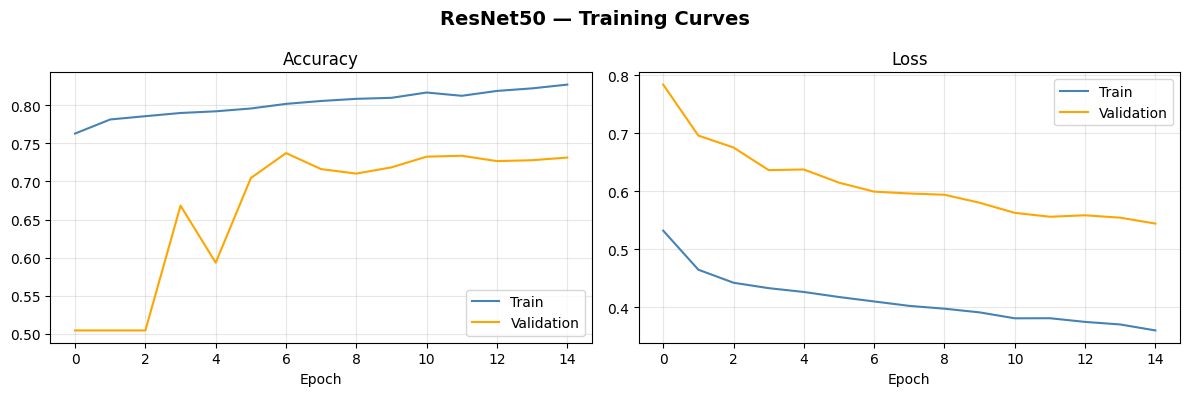

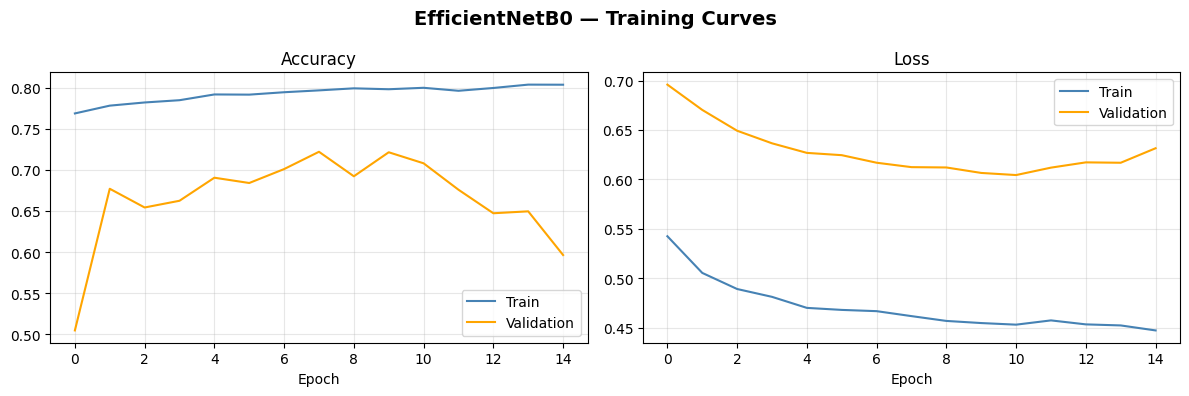

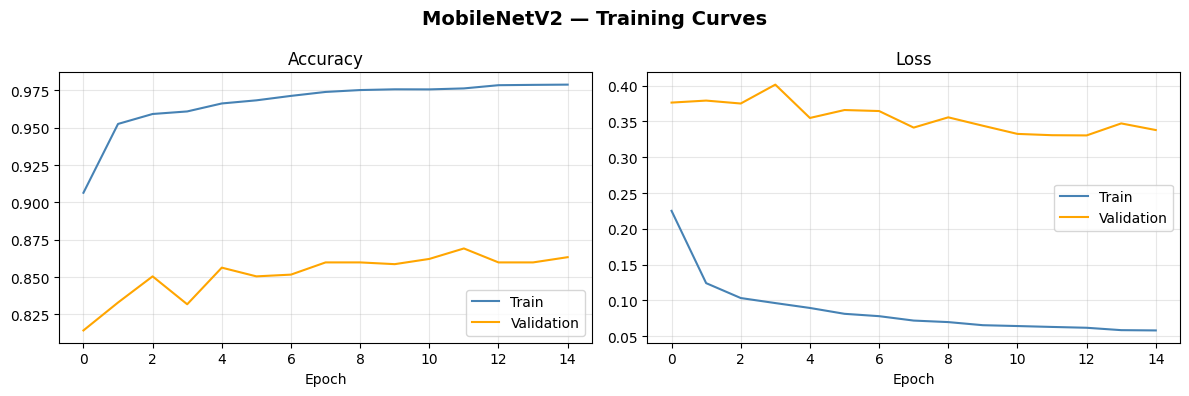

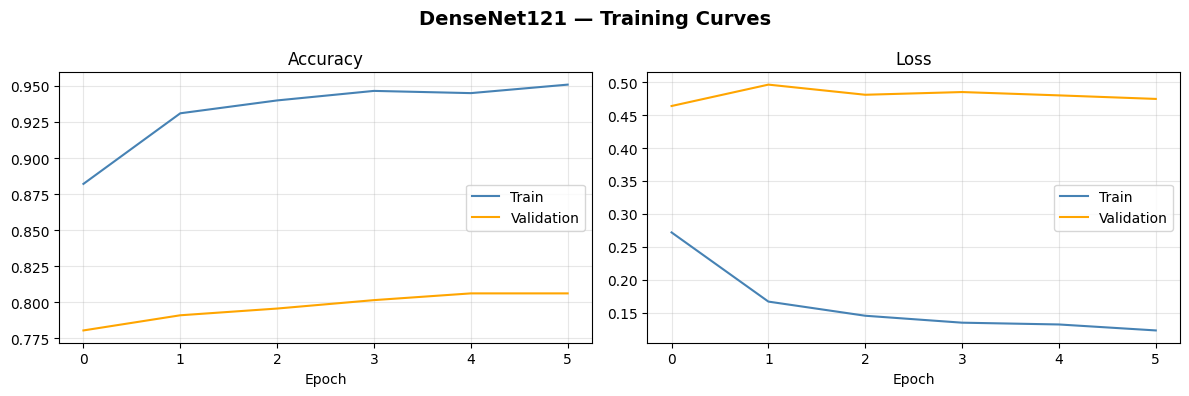

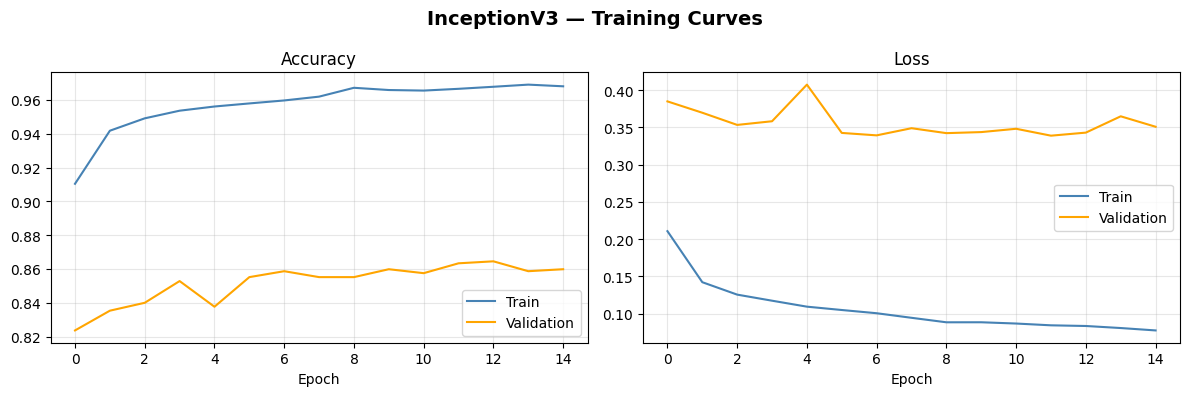

✅ Training curves saved.


In [9]:
# ==================== 7. PER-MODEL TRAINING CURVES ====================
 
for name, history in histories.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{name} — Training Curves", fontsize=14, fontweight='bold')
 
    axes[0].plot(history.history['accuracy'],     label='Train',      color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Validation', color='orange')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
 
    axes[1].plot(history.history['loss'],     label='Train',      color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Validation', color='orange')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.savefig(f'{name}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
 
print("✅ Training curves saved.")

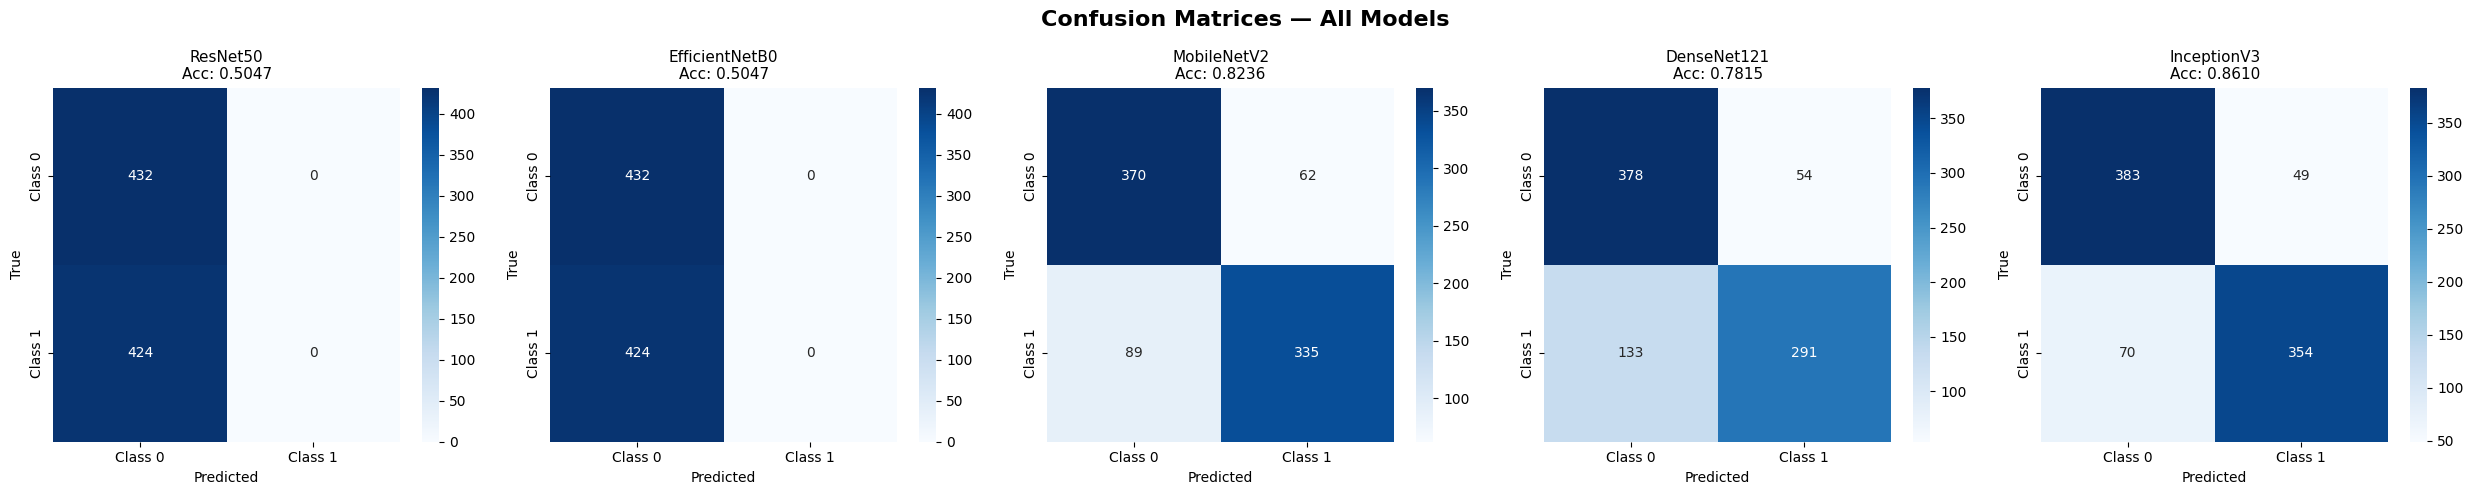

✅ Confusion matrices saved.


In [10]:
# ==================== 8. CONFUSION MATRICES (all models) ====================
 
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
fig.suptitle("Confusion Matrices — All Models", fontsize=16, fontweight='bold')
 
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Class 0', 'Class 1'],
        yticklabels=['Class 0', 'Class 1'],
    )
    ax.set_title(f"{name}\nAcc: {res['acc']:.4f}", fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
 
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Confusion matrices saved.")

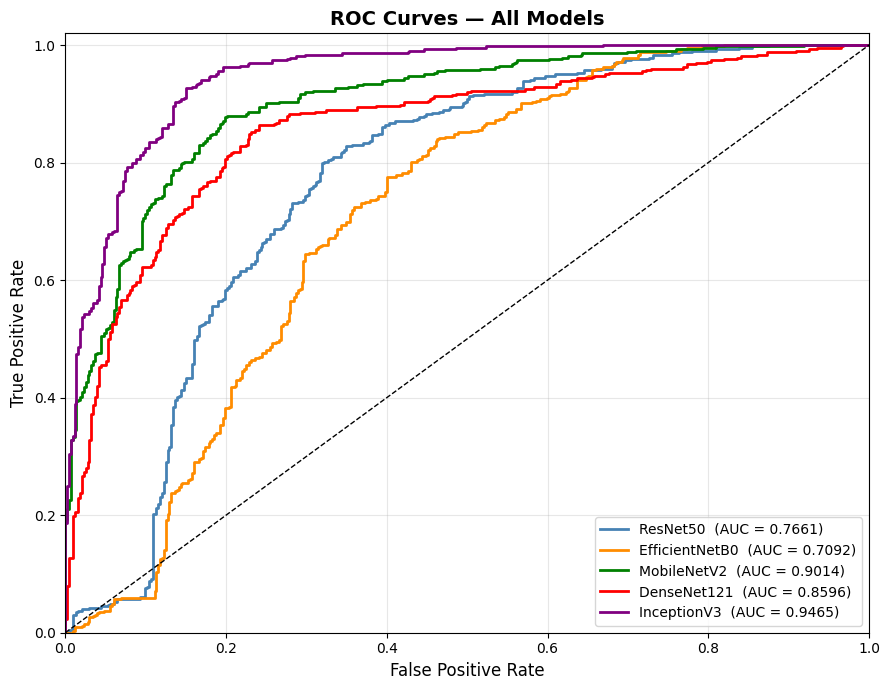

✅ ROC curves saved.


In [11]:
# ==================== 9. ROC CURVES (all models on one plot) ====================
 
plt.figure(figsize=(9, 7))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']
 
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name}  (AUC = {roc_auc:.4f})")
 
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✅ ROC curves saved.")

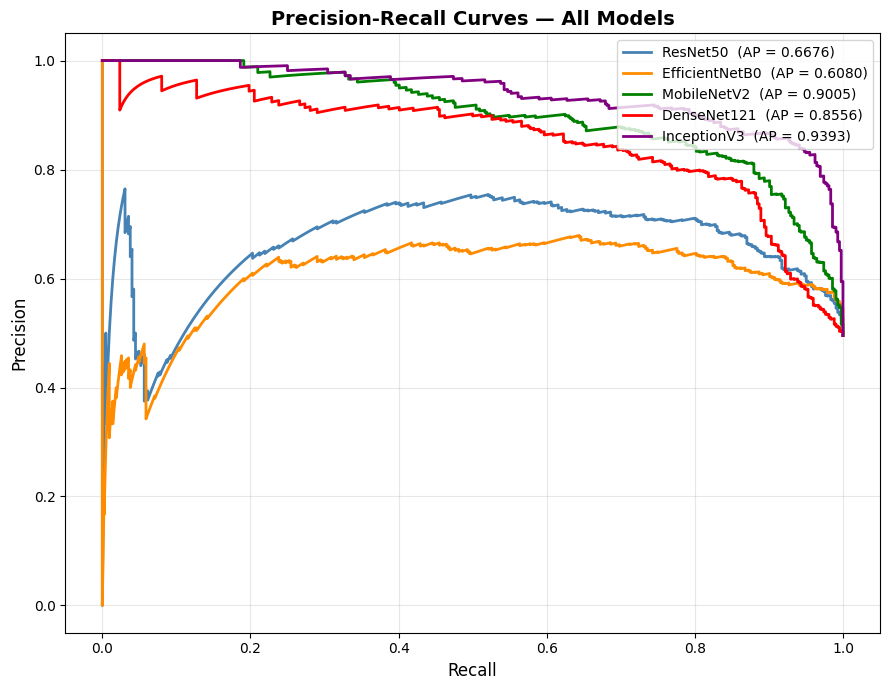

✅ Precision-Recall curves saved.


In [12]:
# ==================== 10. PRECISION-RECALL CURVES (all models) ====================
 
plt.figure(figsize=(9, 7))
 
for (name, res), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(res['y_true'], res['y_prob'])
    ap = average_precision_score(res['y_true'], res['y_prob'])
    plt.plot(recall, precision, color=color, lw=2,
             label=f"{name}  (AP = {ap:.4f})")
 
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Precision-Recall curves saved.")

In [13]:

# ==================== 11. SUMMARY TABLE ====================
 
from sklearn.metrics import f1_score, precision_score, recall_score
 
print("\n" + "=" * 85)
print(f"{'Model':<18} {'Test Acc':>10} {'Test Loss':>10} {'F1':>8} {'Precision':>10} {'Recall':>8} {'AUC':>8}")
print("=" * 85)
 
for name, res in results.items():
    f1   = f1_score       (res['y_true'], res['y_pred'])
    prec = precision_score(res['y_true'], res['y_pred'])
    rec  = recall_score   (res['y_true'], res['y_pred'])
    _, _, roc_auc_val = (lambda fpr, tpr, _: (fpr, tpr, auc(fpr, tpr)))(
        *roc_curve(res['y_true'], res['y_prob'])
    )
    print(f"{name:<18} {res['acc']:>10.4f} {res['loss']:>10.4f} "
          f"{f1:>8.4f} {prec:>10.4f} {rec:>8.4f} {roc_auc_val:>8.4f}")
 
print("=" * 85)


Model                Test Acc  Test Loss       F1  Precision   Recall      AUC
ResNet50               0.5047     0.8551   0.0000     0.0000   0.0000   0.7661
EfficientNetB0         0.5047     0.8695   0.0000     0.0000   0.0000   0.7092
MobileNetV2            0.8236     0.5058   0.8161     0.8438   0.7901   0.9014
DenseNet121            0.7815     0.6724   0.7568     0.8435   0.6863   0.8596
InceptionV3            0.8610     0.3045   0.8561     0.8784   0.8349   0.9465


In [14]:
# ==================== 12. GRAD-CAM (ResNet50 only) ====================
 
def get_img_array(img_tensor):
    img = img_tensor.numpy()
    img = (img * 255).astype(np.uint8)
    return img
 
 
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = 0        # binary sigmoid
        class_channel = preds[:, pred_index]
 
    grads        = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
 
    heatmap = last_conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()
 
 
# Find last Conv2D inside ResNet50 base
resnet_model      = models["ResNet50"]
last_conv_layer   = None
for layer in resnet_model.layers[0].layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break
 
print(f"\nGrad-CAM using conv layer: {last_conv_layer}")
 
plt.figure(figsize=(18, 6))
sample_count = 0
 
for images, labels in test_ds.take(1):
    for i in range(min(6, len(images))):
        img_tensor = tf.expand_dims(images[i], axis=0)
 
        pred       = resnet_model.predict(img_tensor, verbose=0)[0][0]
        pred_class = 1 if pred > 0.5 else 0
        true_class = labels[i].numpy()
 
        heatmap = make_gradcam_heatmap(img_tensor, resnet_model, last_conv_layer)
        heatmap = cv2.resize(heatmap, (224, 224))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
 
        original_img      = get_img_array(images[i])
        superimposed_img  = np.uint8(heatmap * 0.4 + original_img)
 
        ax1 = plt.subplot(2, 6, sample_count + 1)
        ax1.imshow(original_img)
        correct = "✓" if pred_class == true_class else "✗"
        ax1.set_title(f"True:{true_class} | Pred:{pred_class:.2f} {correct}", fontsize=8)
        ax1.axis('off')
 
        ax2 = plt.subplot(2, 6, sample_count + 7)
        ax2.imshow(superimposed_img)
        ax2.set_title("Grad-CAM", fontsize=8)
        ax2.axis('off')
 
        sample_count += 1
 
plt.suptitle("Grad-CAM Visualization — ResNet50 (What the Model is Looking At)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_resnet50.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Grad-CAM visualization saved.")


Grad-CAM using conv layer: conv5_block3_3_conv


ValueError: No such layer: conv5_block3_3_conv. Existing layers are: ['resnet50', 'global_average_pooling2d', 'dropout', 'dense', 'dropout_1', 'dense_1'].

<Figure size 1800x600 with 0 Axes>


🔥 Grad-CAM: ResNet50
    Using conv layer: conv5_block3_3_conv
  ❌ Could not build Grad-CAM model: The layer ResNet50 has never been called and thus has no defined output.

🔥 Grad-CAM: EfficientNetB0
    Using conv layer: top_conv
  ❌ Could not build Grad-CAM model: The layer EfficientNetB0 has never been called and thus has no defined output.

🔥 Grad-CAM: MobileNetV2
    Using conv layer: Conv_1
  ❌ Could not build Grad-CAM model: The layer MobileNetV2 has never been called and thus has no defined output.

🔥 Grad-CAM: DenseNet121
    Using conv layer: conv5_block16_2_conv
  ❌ Could not build Grad-CAM model: The layer DenseNet121 has never been called and thus has no defined output.

🔥 Grad-CAM: InceptionV3
    Using conv layer: conv2d_93
  ⚠️ Sample 0 skipped: "Exception encountered when calling Functional.call().\n\n\x1b133045587456848\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=None\n  • mask=None\n  • k

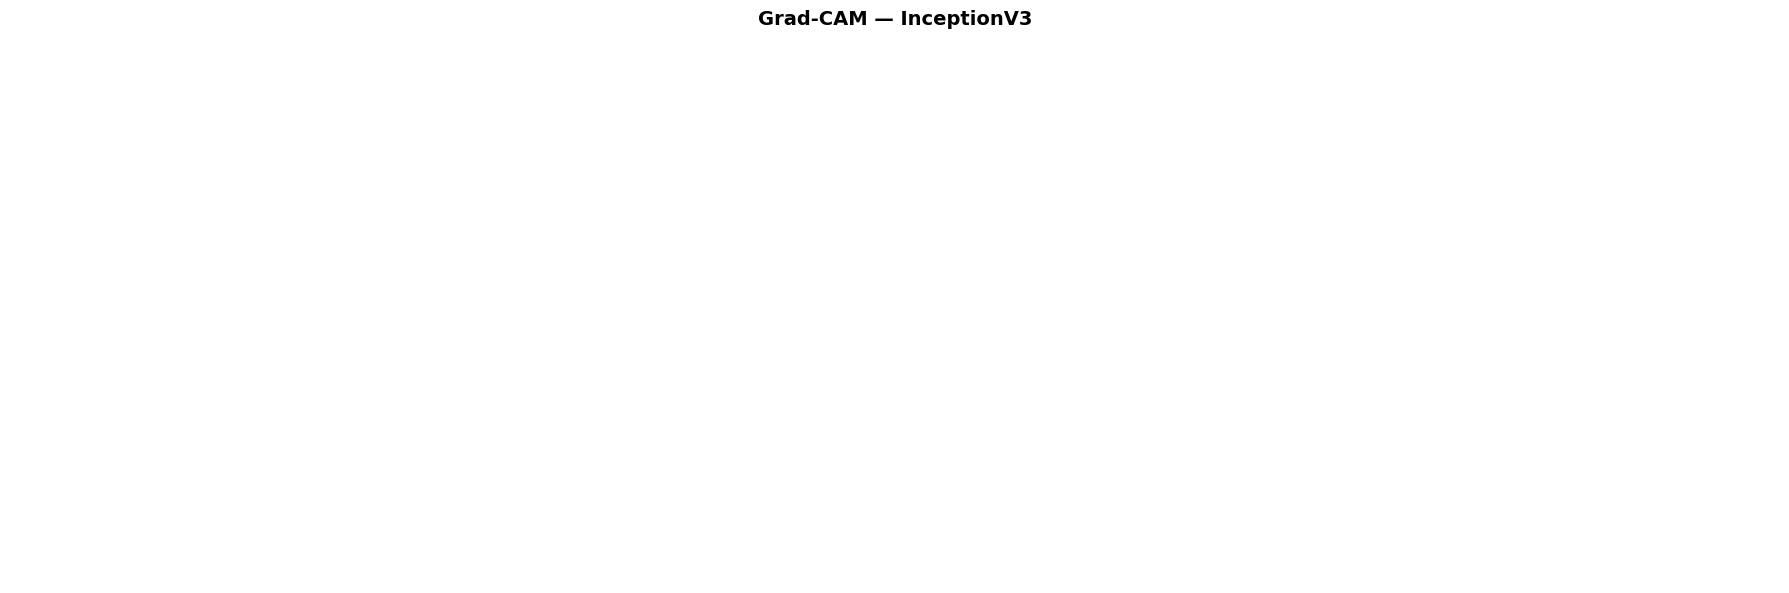

  ✅ Saved gradcam_InceptionV3.png

✅ Grad-CAM complete for all 5 models!


In [16]:
# ==================== GRAD-CAM ALL 5 MODELS ====================

def get_gradcam_overlay(img_tensor, gradcam_model):
    with tf.GradientTape() as tape:
        conv_output, preds = gradcam_model(img_tensor)
        class_channel = preds[:, 0]

    grads        = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap      = heatmap.numpy()

    heatmap_r = cv2.resize(heatmap, (224, 224))
    colored   = cv2.applyColorMap(np.uint8(255 * heatmap_r), cv2.COLORMAP_JET)
    original  = (img_tensor[0].numpy() * 255).astype(np.uint8)
    overlay   = np.uint8(colored * 0.4 + original)
    pred      = preds[0][0].numpy()
    return original, overlay, pred


def build_gradcam_model(model):
    """
    Find the last Conv2D by actually tracing through the model's
    compute graph — works even after clear_session().
    """
    last_conv_output = None
    last_conv_name   = None

    # Walk every layer in the full model graph (includes nested sub-models)
    def find_last_conv(m):
        nonlocal last_conv_output, last_conv_name
        for layer in m.layers:
            if isinstance(layer, tf.keras.Model):
                find_last_conv(layer)          # recurse into sub-model
            elif isinstance(layer, tf.keras.layers.Conv2D):
                try:
                    last_conv_output = layer.output
                    last_conv_name   = layer.name
                except Exception:
                    pass

    find_last_conv(model)

    if last_conv_output is None:
        raise ValueError("No Conv2D layer found in model.")

    print(f"    Using conv layer: {last_conv_name}")
    gradcam_model = tf.keras.Model(
        inputs  = model.inputs,
        outputs = [last_conv_output, model.output]
    )
    return gradcam_model


# ── Plot for all 5 models ────────────────────────────────────────
for name, model in models.items():
    print(f"\n🔥 Grad-CAM: {name}")

    try:
        gradcam_model = build_gradcam_model(model)
    except Exception as e:
        print(f"  ❌ Could not build Grad-CAM model: {e}")
        continue

    fig, axes_rows = plt.subplots(2, 6, figsize=(18, 6))
    fig.suptitle(f"Grad-CAM — {name}", fontsize=14, fontweight='bold')

    sample_count = 0
    for images, labels in test_ds.take(1):
        for i in range(min(6, len(images))):
            img_tensor = tf.expand_dims(images[i], axis=0)
            true_class = labels[i].numpy()

            try:
                original, overlay, pred = get_gradcam_overlay(img_tensor, gradcam_model)
                pred_class = 1 if pred > 0.5 else 0
                correct    = "✓" if pred_class == true_class else "✗"

                axes_rows[0][sample_count].imshow(original)
                axes_rows[0][sample_count].set_title(
                    f"True:{true_class} Pred:{pred:.2f} {correct}", fontsize=7)
                axes_rows[0][sample_count].axis('off')

                axes_rows[1][sample_count].imshow(overlay)
                axes_rows[1][sample_count].set_title("Grad-CAM", fontsize=7)
                axes_rows[1][sample_count].axis('off')

            except Exception as e:
                print(f"  ⚠️ Sample {i} skipped: {e}")
                axes_rows[0][sample_count].axis('off')
                axes_rows[1][sample_count].axis('off')

            sample_count += 1

    plt.tight_layout()
    plt.savefig(f'gradcam_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  ✅ Saved gradcam_{name}.png")

print("\n✅ Grad-CAM complete for all 5 models!")

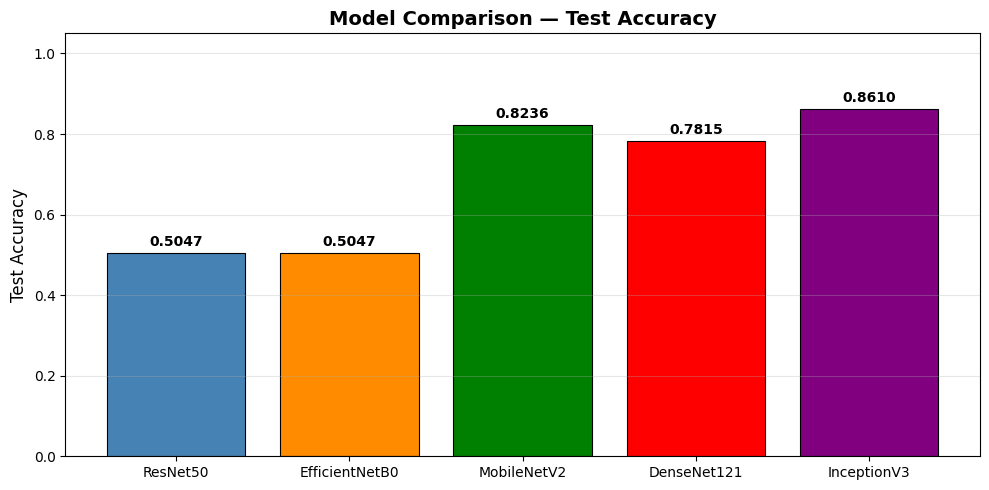


✅ All training, evaluation, and visualizations complete!
📁 Saved files:
   • ResNet50_training_curves.png
   • EfficientNetB0_training_curves.png
   • MobileNetV2_training_curves.png
   • DenseNet121_training_curves.png
   • InceptionV3_training_curves.png
   • all_confusion_matrices.png
   • all_roc_curves.png
   • all_pr_curves.png
   • gradcam_resnet50.png
   • model_accuracy_comparison.png


In [17]:
# ==================== 13. FINAL ACCURACY BAR CHART ====================
 
model_names = list(results.keys())
test_accs   = [results[n]['acc'] for n in model_names]
 
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, test_accs, color=colors, edgecolor='black', linewidth=0.8)
plt.ylim(0, 1.05)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
 
print("\n✅ All training, evaluation, and visualizations complete!")
print("📁 Saved files:")
for name in model_names:
    print(f"   • {name}_training_curves.png")
print("   • all_confusion_matrices.png")
print("   • all_roc_curves.png")
print("   • all_pr_curves.png")
print("   • gradcam_resnet50.png")
print("   • model_accuracy_comparison.png")